Week - 5  Building a CNN for Image Classification

Design and implement a CNN model (with 4+ layers of convolutions) to classify multi category image datasets. Use the concept of regularization and dropout while designing the CNN model.

Use CIFAR-10 dataset.

Record the Training accuracy and Test accuracy corresponding to the following architectures:

       a. Base Model

       b. Model with L1 Regularization

       c. Model with L2 Regularization

       d. Model with Dropout

       e. Model with both L2 (or L1) and Dropout

Dataset:  https://www.kaggle.com/c/cifar-10/

**Base Model:**

In [ ]:
import keras

from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
(train_X,train_Y), (test_X,test_Y) = cifar10.load_data()
train_X = train_X.reshape(-1, 28,28, 1)
test_X = test_X.reshape(-1, 28,28, 1)
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255
test_X = test_X / 255
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)
model = Sequential()
model.add(Conv2D(256, (3,3), input_shape=(28, 28, 1)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, (3,3), input_shape=(28, 28, 1)))
model.add(Activation('relu'))
#model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(28, (3,3)))
model.add(Activation('relu'))
#model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64))
model.add(Dense(10))
model.add(Activation('softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
model.fit(train_X, train_Y_one_hot, batch_size=64, epochs=5)
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)
print('Test loss', test_loss)
print('Test accuracy', test_acc)
predictions = model.predict(test_X)
print(np.argmax(np.round(predictions[0])))
plt.imshow(test_X[0].reshape(28, 28), cmap = plt.cm.binary)
plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 330s 2us/step


ValueError: cannot reshape array of size 153600000 into shape (28,28,1)

**Model with L1 Regularization**

In [ ]:
# L1 Regularizer
import keras
from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.regularizers import l1
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
(train_X,train_Y), (test_X,test_Y) = cifar10.load_data()
train_X = train_X.reshape(-1, 28,28, 1)
test_X = test_X.reshape(-1, 28,28, 1)
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255
test_X = test_X / 255
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)
model = Sequential()
model.add(Conv2D(256,(3,3),input_shape=(28, 28, 1),kernel_regularizer=l1(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128, (3,3),kernel_regularizer=l1(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

**Model with L2 Regularization**

In [ ]:
# L2 regularizer
import keras
from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.regularizers import l2
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
(train_X,train_Y), (test_X,test_Y) = cifar10.load_data()
train_X = train_X.reshape(-1, 28,28, 1)

test_X = test_X.reshape(-1, 28,28, 1)
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255
test_X = test_X / 255
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)
model = Sequential()
model.add(Conv2D(256,(3,3),input_shape=(28,28,1), kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128, (3,3),))

#kernel_regularizer=l2(0.01)
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, (3,3), input_shape=(28, 28, 1),))
#kernel_regularizer=l2(0.01)


model.add(Activation('relu'))
#model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(28, (3,3),))

#kernel_regularizer=l2(0.01)


model.add(Activation('relu'))
#model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64))
model.add(Dense(10))
model.add(Activation('softmax'))
model.compile(loss=keras.losses.categorical_crossentropy,optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
model.fit(train_X, train_Y_one_hot, epochs=5)
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)
print('Test loss', test_loss)
print('Test accuracy', test_acc)

**Model with Dropout**

In [ ]:
#Dropout
import keras
from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D, Dropout
from keras.models import Sequential
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
(train_X,train_Y), (test_X,test_Y) = cifar10.load_data()
train_X = train_X.reshape(-1, 28,28, 1)
test_X = test_X.reshape(-1, 28,28, 1)
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255
test_X = test_X / 255
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)
model = Sequential()
model.add(Conv2D(256, (3,3), input_shape=(28, 28, 1)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
Dropout(0.20)
model.add(Conv2D(128, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
#Dropout(0.20)
model.add(Conv2D(64, (3,3), input_shape=(28, 28, 1)))
model.add(Activation('relu'))
#model.add(MaxPooling2D(pool_size=(2,2)))
#Dropout(0.20)
model.add(Conv2D(28, (3,3)))
model.add(Activation('relu'))
predictions = model.predict(test_X)
print(np.argmax(np.round(predictions[0])))
plt.imshow(test_X[0].reshape(28, 28), cmap = plt.cm.binary)
plt.show()

**Model with both L2 (or L1) and Dropout**

In [ ]:
# L2 regularizer and Dropout
import keras
from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.regularizers import l2
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
(train_X,train_Y), (test_X,test_Y) = cifar10.load_data()
train_X = train_X.reshape(-1, 28,28, 1)
test_X = test_X.reshape(-1, 28,28, 1)
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X / 255
test_X = test_X / 255
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

R-20

model = Sequential()
model.add(Conv2D(256, (3,3), input_shape=(28, 28, 1), kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
Dropout(0.20)

model.add(Conv2D(128, (3,3),

#kernel_regularizer=l2(0.01)

))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, (3,3), input_shape=(28, 28, 1),))
#kernel_regularizer=l2(0.01)


model.add(Activation('relu'))
#model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(28, (3,3),))

#kernel_regularizer=l2(0.01)


model.add(Activation('relu'))
#model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64))
model.add(Dense(10))
model.add(Activation('softmax'))
model.compile(loss=keras.losses.categorical_crossentropy,optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
model.fit(train_X, train_Y_one_hot, epochs=5)
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)
print('Test loss', test_loss)
print('Test accuracy', test_acc)
predictions = model.predict(test_X)
print(np.argmax(np.round(predictions[0])))
plt.imshow(test_X[0].reshape(28, 28), cmap = plt.cm.binary)
plt.show()

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.3937 - loss: 1.6470
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5472 - loss: 1.2661
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6114 - loss: 1.1027
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6513 - loss: 0.9877
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6811 - loss: 0.9117
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6804 - loss: 0.9306
Test loss: 0.9305638670921326
Test accuracy: 0.680400013923645
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted Class: 3


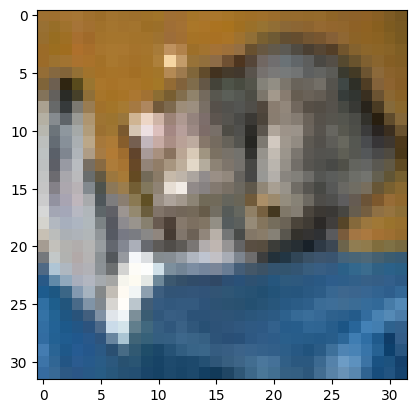

In [ ]:
#1. Base model

import keras
from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(train_X, train_Y), (test_X, test_Y) = cifar10.load_data()

# Normalize data
train_X = train_X.astype('float32') / 255.0
test_X = test_X.astype('float32') / 255.0

# One-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Build CNN model
model = Sequential()

model.add(Conv2D(256, (3,3), input_shape=(32,32,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3)))
model.add(Activation('relu'))

model.add(Conv2D(28, (3,3)))
model.add(Activation('relu'))

model.add(Flatten())

model.add(Dense(64))
model.add(Activation('relu'))

model.add(Dense(10))
model.add(Activation('softmax'))

# Compile model
model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Train model
model.fit(train_X, train_Y_one_hot, batch_size=64, epochs=5)

# Evaluate model
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)

print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

# Prediction
predictions = model.predict(test_X)

print("Predicted Class:", np.argmax(predictions[0]))

# Display image
plt.imshow(test_X[0])
plt.show()

In [ ]:
#2. L1 Regularizer

import keras
from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.regularizers import l1
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(train_X, train_Y), (test_X, test_Y) = cifar10.load_data()

# Normalize data
train_X = train_X.astype('float32') / 255.0
test_X = test_X.astype('float32') / 255.0

# One-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Build model
model = Sequential()

model.add(Conv2D(256, (3,3),
                 input_shape=(32,32,3),
                 kernel_regularizer=l1(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3),
                 kernel_regularizer=l1(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3),
                 kernel_regularizer=l1(0.01)))
model.add(Activation('relu'))

model.add(Flatten())

model.add(Dense(64, kernel_regularizer=l1(0.01)))
model.add(Activation('relu'))

model.add(Dense(10))
model.add(Activation('softmax'))

# Compile
model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Train
model.fit(train_X, train_Y_one_hot,
          batch_size=64,
          epochs=5)

# Evaluate
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.0972 - loss: 5.5285
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.0976 - loss: 2.8475
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.0957 - loss: 2.8475
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.0974 - loss: 2.8475
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.0957 - loss: 2.8474
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1000 - loss: 2.8514
Test Loss: 2.8513636589050293
Test Accuracy: 0.10000000149011612


In [ ]:
#3. L2 Regularizer

import keras
from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.regularizers import l2
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(train_X, train_Y), (test_X, test_Y) = cifar10.load_data()

# Normalize data
train_X = train_X.astype('float32') / 255.0
test_X = test_X.astype('float32') / 255.0

# One-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Build model
model = Sequential()

model.add(Conv2D(256, (3,3),
                 input_shape=(32,32,3),
                 kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3),
                 kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3),
                 kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))

model.add(Conv2D(28, (3,3),
                 kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))

model.add(Flatten())

model.add(Dense(64,
                kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))

model.add(Dense(10))
model.add(Activation('softmax'))

# Compile
model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Train
model.fit(train_X, train_Y_one_hot,
          epochs=5,
          batch_size=64)

# Evaluate
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)

print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.2465 - loss: 2.2324
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3425 - loss: 1.9087
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3905 - loss: 1.8165
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4198 - loss: 1.7567
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4429 - loss: 1.7085
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4348 - loss: 1.7489
Test loss: 1.7488515377044678
Test accuracy: 0.43479999899864197


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.3438 - loss: 1.7652
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4971 - loss: 1.3846
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5551 - loss: 1.2414
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5917 - loss: 1.1480
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6223 - loss: 1.0712
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6473 - loss: 1.0073
Test Loss: 1.0073106288909912
Test Accuracy: 0.6473000049591064
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Predicted Class: 3


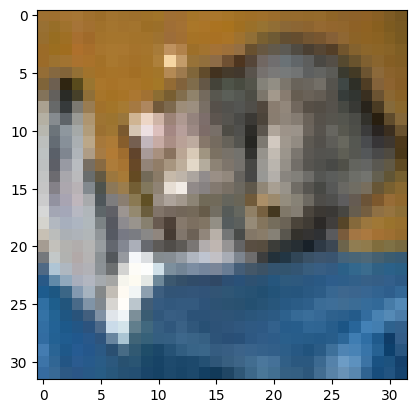

In [ ]:
# Dropout CNN

import keras
from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D, Dropout
from keras.models import Sequential
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(train_X, train_Y), (test_X, test_Y) = cifar10.load_data()

# Normalize data
train_X = train_X.astype('float32') / 255.0
test_X = test_X.astype('float32') / 255.0

# One-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Build model
model = Sequential()

model.add(Conv2D(256, (3,3), input_shape=(32,32,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.20))

model.add(Conv2D(128, (3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.20))

model.add(Conv2D(64, (3,3)))
model.add(Activation('relu'))
model.add(Dropout(0.20))

model.add(Conv2D(28, (3,3)))
model.add(Activation('relu'))

model.add(Flatten())

model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.20))

model.add(Dense(10))
model.add(Activation('softmax'))

# Compile
model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Train
model.fit(train_X, train_Y_one_hot,
          batch_size=64,
          epochs=5)

# Evaluate
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

# Prediction
predictions = model.predict(test_X)

print("Predicted Class:", np.argmax(predictions[0]))

# Display image
plt.imshow(test_X[0])
plt.show()

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.2065 - loss: 2.2855
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2540 - loss: 2.0023
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3113 - loss: 1.9233
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3285 - loss: 1.8938
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3533 - loss: 1.8623
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3821 - loss: 1.7885
Test loss: 1.7885363101959229
Test accuracy: 0.382099986076355
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Predicted Class: 3


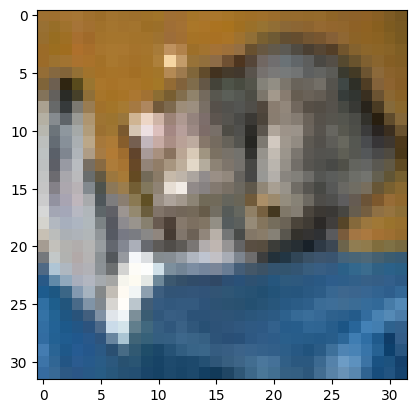

In [ ]:
# L2 Regularizer + Dropout

import keras
from keras.datasets import cifar10
from keras.layers import Dense, Activation, Flatten, Conv2D
from keras.layers import MaxPooling2D, Dropout
from keras.models import Sequential
from keras.regularizers import l2
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(train_X, train_Y), (test_X, test_Y) = cifar10.load_data()

# Normalize data
train_X = train_X.astype('float32') / 255.0
test_X = test_X.astype('float32') / 255.0

# One-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Build model
model = Sequential()

model.add(Conv2D(256, (3,3),
                 input_shape=(32,32,3),
                 kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.20))

model.add(Conv2D(128, (3,3),
                 kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.20))

model.add(Conv2D(64, (3,3),
                 kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(Dropout(0.20))

model.add(Conv2D(28, (3,3),
                 kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))

model.add(Flatten())

model.add(Dense(64,
                kernel_regularizer=l2(0.01)))
model.add(Activation('relu'))
model.add(Dropout(0.20))

model.add(Dense(10))
model.add(Activation('softmax'))

# Compile model
model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

# Train model
model.fit(train_X, train_Y_one_hot,
          epochs=5,
          batch_size=64)

# Evaluate
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)

print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

# Prediction
predictions = model.predict(test_X)

print("Predicted Class:", np.argmax(predictions[0]))

# Display image
plt.imshow(test_X[0])
plt.show()